# Investigate the observed secondary events
- Number of events at different cutoffs
- Comparison of number of events with junction diversity
- Length distribution of secondary structural events
- MGE annotations of events

In [ ]:
# set working directory to project folder
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd

from junction_analysis.helpers import read_gff3_annotations, read_gff3_cds_products, read_gff3_trna
from junction_analysis.plotting import plot_event_length_distribution, plot_marginal_scatter, plot_clustering_threshold_sweep, plot_event_mge_stacked_bar, plot_event_counts_distribution
from junction_analysis.annotate_insertions import combine_all_junctions_summaries, count_events_per_junction, deduplicate_events, annotate_events_with_mges

In [2]:
jdf_all = pd.read_csv("../results/junction_summary_df.csv")

summaries = combine_all_junctions_summaries("../results/atb_lookup", save_df=False)

## Number of events at different cutoffs

In [8]:
all_results = []
tree_path = "../config/polished_tree.nwk"
jdf_all = pd.read_csv("../results/junction_summary_df.csv")


for thresh in ['05', '1', '2', '3', '4', '5', '6']:
    cluster_df = pd.read_csv(f"../results/consensus_analysis/cluster_maps_0_00{thresh}.csv")
    n_junctions_with_clusters = len(cluster_df[cluster_df['n_clusters']>1])
    n_additional_clusters = cluster_df.n_clusters.sum() - len(cluster_df)

    summaries = combine_all_junctions_summaries(f"../results/atb_lookup_000{thresh}", save_df=True)
    deduplicated_events_df = deduplicate_events(summaries, save_path=f"../results/atb_lookup_000{thresh}/deduplicated_events.csv")  
    counts_df = count_events_per_junction(deduplicated_events_df, min_length=200, save_path=f"../results/atb_lookup_000{thresh}/event_counts_per_junction.csv")

    n_insertions, n_deletions, n_translocations, n_inversions, n_events = counts_df[['n_insertion', 'n_deletion', 'n_translocation', 'n_inversion', 'n_events']].sum()

    per_cluster_parsimony_df = pd.read_csv(f"../results/consensus_analysis/parsimonious_clusters_000{thresh}.csv")
    per_cluster_parsimony_df = per_cluster_parsimony_df[per_cluster_parsimony_df.junction_name.isin(jdf_all.junction_name.to_list())]
    multi_cluster_df = per_cluster_parsimony_df[per_cluster_parsimony_df["n_clusters"] > 1].copy()
    n_clusters_not_consistent = (multi_cluster_df["n_parsimony_steps"] > 1).sum()
    inconsistant_junctions = multi_cluster_df.loc[multi_cluster_df["n_parsimony_steps"] > 1, "junction_name"].nunique()
    n_clusters_in_multi_cluster_junctions = len(multi_cluster_df) # total number of clusters in junctions with > 1 cluster

    result_dict = {
        "threshold": f"0.00{thresh}",
        "n_junctions_with_clusters": len(per_cluster_parsimony_df[per_cluster_parsimony_df["n_clusters"] > 1].junction_name.unique()),
        "n_additional_clusters": n_additional_clusters,
        "n_insertions": n_insertions,
        "n_deletions": n_deletions,
        "n_translocations": n_translocations,
        "n_inversions": n_inversions,
        "n_events": n_events,
        "n_inconsistant_cluster": n_clusters_not_consistent,
        "n_inconsistant_junctions": inconsistant_junctions,
        "n_cluster_multicluster_junctions": n_clusters_in_multi_cluster_junctions, # different from n_additional clusters because it only considers some junctions instead of one cluster less per junction
    }

    all_results.append(result_dict)

results_df = pd.DataFrame(all_results)

Saved insertions summary to ../results/atb_lookup_00005/insertions/all_junctions_insertions.csv
No ambiguous_insertions found across any junction.
Saved deletions summary to ../results/atb_lookup_00005/deletions/all_junctions_deletions.csv
Saved translocations summary to ../results/atb_lookup_00005/translocations/all_junctions_translocations.csv
Saved inversions summary to ../results/atb_lookup_00005/inversions/all_junctions_inversions.csv
Saved deduplicated events to ../results/atb_lookup_00005/deduplicated_events.csv
Saved event counts to ../results/atb_lookup_00005/event_counts_per_junction.csv
Saved insertions summary to ../results/atb_lookup_0001/insertions/all_junctions_insertions.csv
No ambiguous_insertions found across any junction.
Saved deletions summary to ../results/atb_lookup_0001/deletions/all_junctions_deletions.csv
Saved translocations summary to ../results/atb_lookup_0001/translocations/all_junctions_translocations.csv
Saved inversions summary to ../results/atb_lookup_

In [9]:
results_df

,threshold,n_junctions_with_clusters,n_additional_clusters,n_insertions,n_deletions,n_translocations,n_inversions,n_events,n_inconsistant_cluster,n_inconsistant_junctions,n_cluster_multicluster_junctions
0,0.0005,247,516,1778.0,285.0,23.0,25.0,2111.0,13,13,731
1,0.001,210,378,1765.0,287.0,49.0,25.0,2126.0,10,10,562
2,0.002,177,327,1780.0,291.0,52.0,26.0,2149.0,11,11,485
3,0.003,148,283,1801.0,306.0,56.0,27.0,2190.0,12,12,414
4,0.004,131,249,1814.0,302.0,55.0,25.0,2196.0,10,10,367
5,0.005,106,199,1806.0,302.0,51.0,25.0,2184.0,8,8,294
6,0.006,83,159,1811.0,308.0,51.0,25.0,2195.0,10,10,234


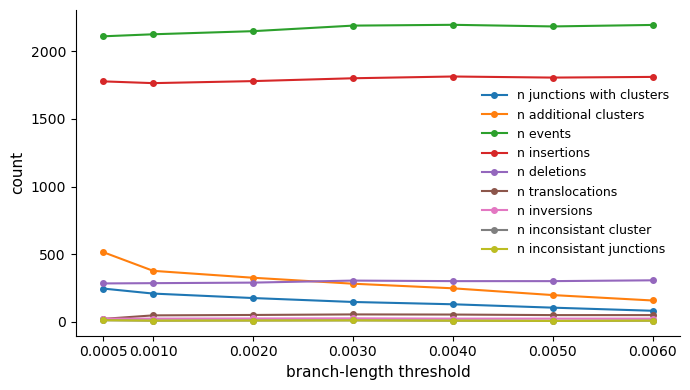

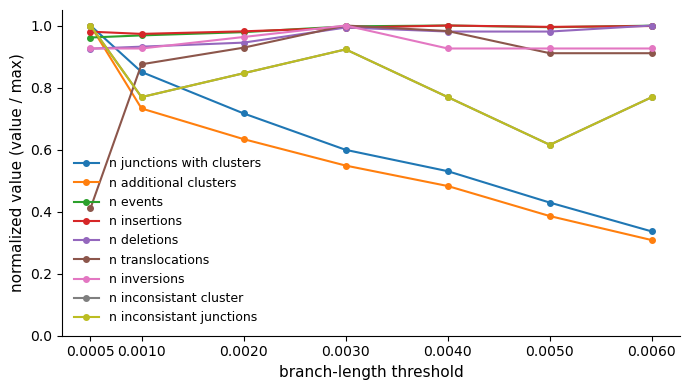

In [10]:
plot_clustering_threshold_sweep(results_df, figsize=(7,4), save_path=None, normalize=False)
plot_clustering_threshold_sweep(results_df, figsize=(7,4), save_path=None, normalize=True)

/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analysis/plotting.py:2134: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



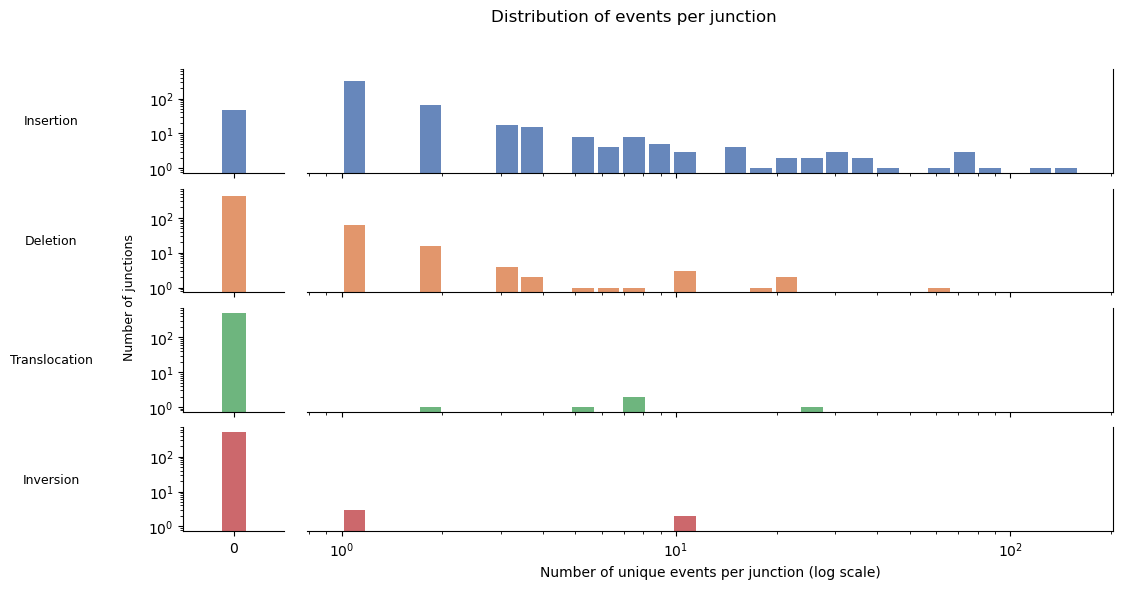

/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analysis/plotting.py:2134: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



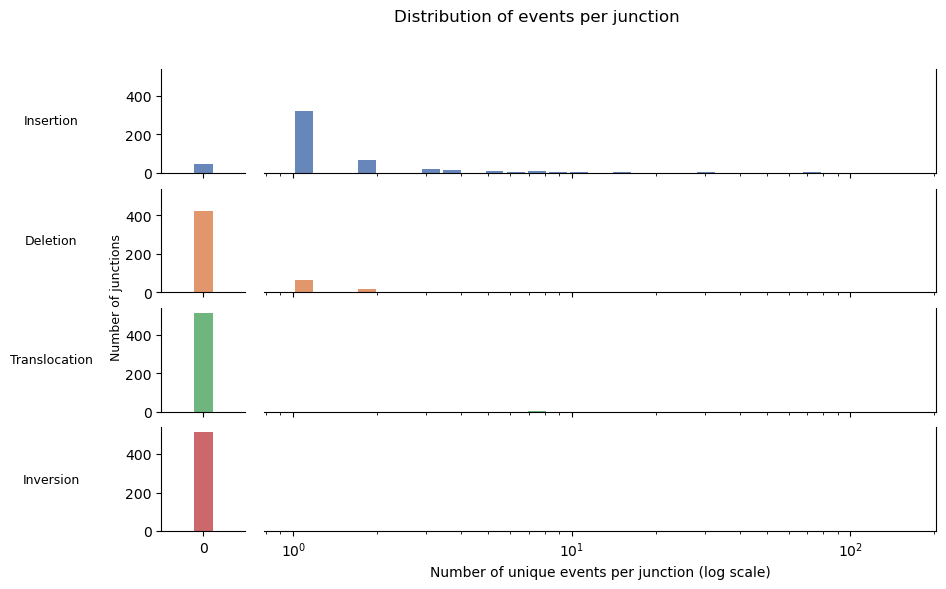

In [21]:
# consider distribution of the number of events per junction

plot_event_counts_distribution(jdf_all, figsize=(12, 6), log_x = True, log_y = True, subplots = True)
plot_event_counts_distribution(jdf_all, figsize=(10, 6), log_x = True, log_y = False, subplots = True)

In [6]:
# final event count for chosen threshold
jdf_all[['n_insertion', 'n_deletion', 'n_translocation', 'n_inversion', 'n_events']].sum()

n_insertion        1765.0
n_deletion          287.0
n_translocation      49.0
n_inversion          25.0
n_events           2126.0
dtype: float64

## Compare number of structural events with junction diversity

Saved figure to ../figures/n_events_junction_diversity.pdf
Saved figure to ../figures/events_over_junction_diversity_by_type.pdf


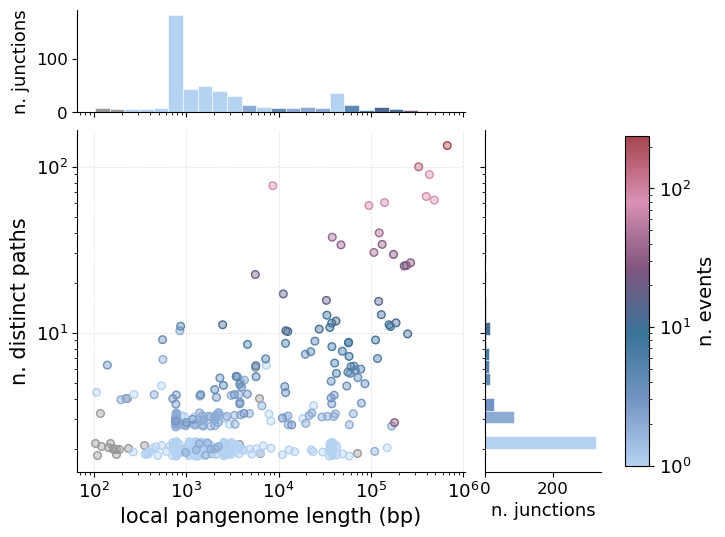

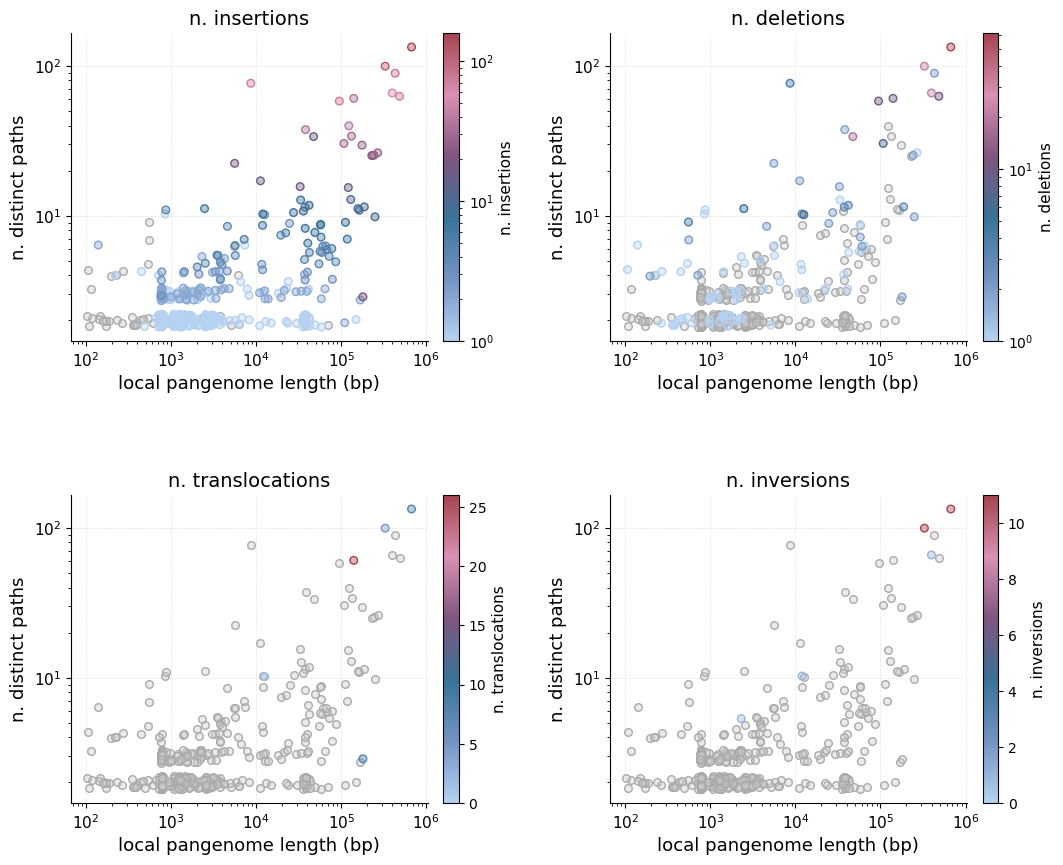

In [19]:
fig, axes = plot_marginal_scatter(                                                                                                                                                                        
      jdf_all,                                                                                                                                                                                         
      x_col="tot_acc_len",                                                                                                                                                                                  
      y_col="n_categories",                                                                                                                                                                                 
      color_by_event_count="n_events",  # or "n_insertion", "n_deletion", etc.                                                                                                                              
      filled=True,
      fill_alpha=0.4,
      edge_alpha=1,
      scatter_size=30,
      point_linewidth=1,
      save_path="../figures/n_events_junction_diversity.pdf",
      figsize=(8,6)                                                                                                                                                                                    
  )

fig, axes = plot_marginal_scatter(                                                                                                                                                                        
    jdf_all,                                                                                                                                                                                         
    x_col="tot_acc_len",                                                                                                                                                                                  
    y_col="n_categories",                                                                                                                                                                                 
    color_by_event_count=["n_insertion", "n_deletion", "n_translocation", "n_inversion"],  # or "n_insertion", "n_deletion", etc.                                                                                                                              
    filled=True,
    fill_alpha=0.4,
    edge_alpha=1,
    scatter_size=30,
    point_linewidth=1,
    log_color_scale=['n_insertion', 'n_deletion'],
    subplot_arrangement=(2, 2),
    figsize=(12, 10),
    shared_colorbar=False,
    save_path = "../figures/events_over_junction_diversity_by_type.pdf"
) 

# bars are colored by the median n. events within their range

MGEs that use integrases to insert into a new location often appear close to tRNA genes. Here we check if the occurence of tRNA genes follows a similar trend to the occurence of secondary structural events likely caused by MGEs.

Saved figure to ../figures/n_trna_junction_diversity.pdf


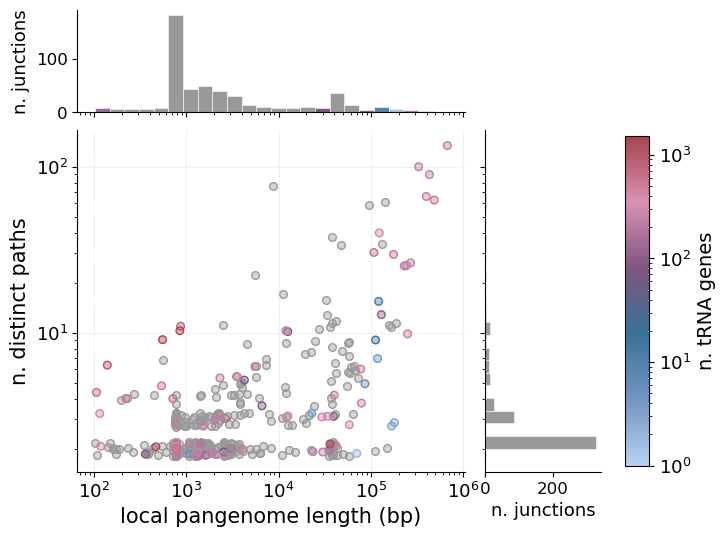

In [18]:
fig, axes = plot_marginal_scatter(                                                                                                                                                                        
      jdf_all,                                                                                                                                                                                         
      x_col="tot_acc_len",                                                                                                                                                                                  
      y_col="n_categories",                                                                                                                                                                                 
      color_by_event_count="n_total_trna",  # or "n_insertion", "n_deletion", etc.
       colorbar_label="n. tRNA genes",                                                                                                                         
      filled=True,
      fill_alpha=0.4,
      edge_alpha=1,
      scatter_size=30,
      point_linewidth=1,
      save_path="../figures/n_trna_junction_diversity.pdf",
      figsize=(8,6)                                                                                                                                                                                    
  ) 

## Investigate length distribution of secondary structural events

Saved figure to ../figures/deletions_cumulative_length.pdf


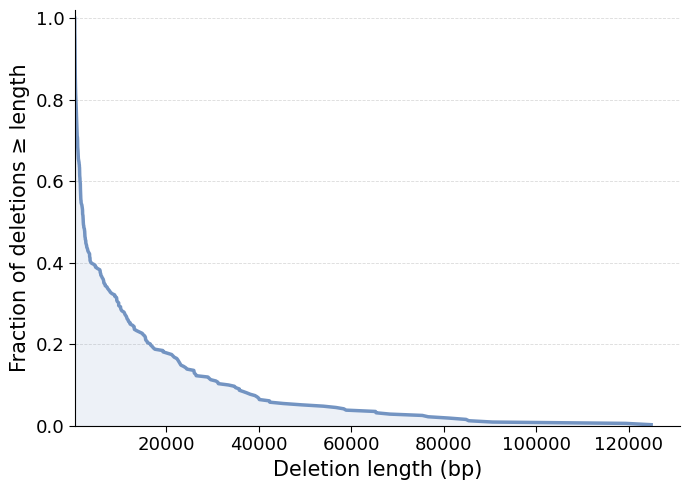

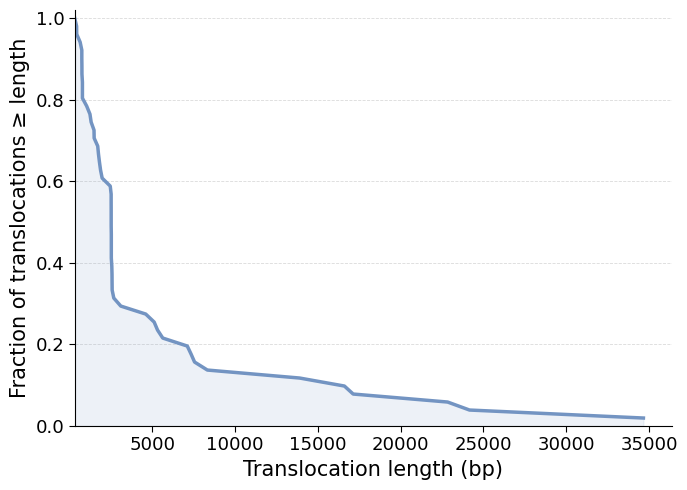

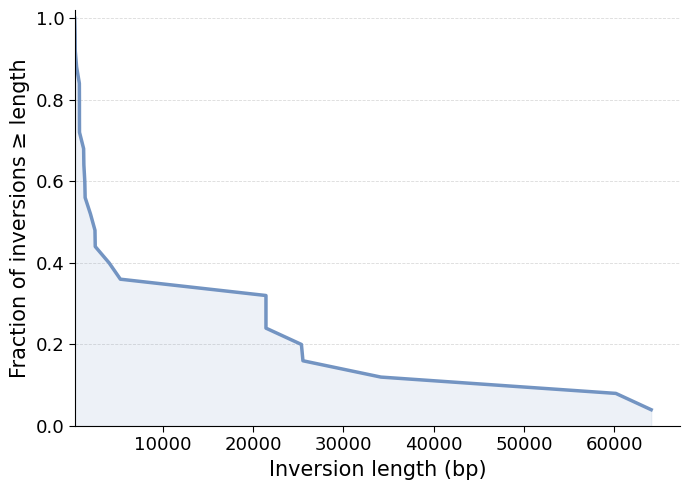

(<Figure size 700x500 with 1 Axes>,
 <Axes: xlabel='Inversion length (bp)', ylabel='Fraction of inversions ≥ length'>)

In [20]:
plot_event_length_distribution(deduplicated_events_df, min_length_threshold=200,                                                                                                                          
                                  log_y=False, log_x=False,                                                                                                                        
                                  filter_below_threshold=True, color_by_mge=True, deletions_only=True, figsize=(7,5), save_path="../figures/deletions_cumulative_length.pdf")

plot_event_length_distribution(deduplicated_events_df, min_length_threshold=200,                                                                                                                          
      log_y=False, log_x=False, filter_below_threshold=True,                                                                                                                                                
      ccdf_event="translocation", figsize=(7,5),                                                                                                                                                            
      #save_path="../figures/translocation_cumulative_length.pdf"
      )                                                                                                                                           
                                                                                                                                                                                                            
plot_event_length_distribution(deduplicated_events_df, min_length_threshold=200,                                                                                                                          
    log_y=False, log_x=False, filter_below_threshold=True,                                                                                                                                                
    ccdf_event="inversion", figsize=(7,5),                                                                                                                                                              
    #save_path="../figures/inversion_cumulative_length.pdf"
    )  

## Annotate events

In [ ]:
# overview how to read functional annotations

junction_name = "RYYAQMEJGY_r__ZTHKZYHPIX_f"
junction_annotations_df = read_gff3_annotations(f"../results/junction_mges/{junction_name}.gff3")
display(junction_annotations_df.head())
cds_products_df = read_gff3_cds_products(f"../results/junction_annotations/{junction_name}.gff")
display(cds_products_df.head())

junction_name = "IHKFSQQUKE_r__KPBYGJHRZJ_f"
tRNA_product_df = read_gff3_trna(f"../results/junction_annotations/{junction_name}.gff")
tRNA_product_df.head()


,seqid,feature,start,end,length,attrs,is_subtype
0,NZ_CP102061.1,IS,1969,2823,854,"{'ID': 'NZ_CP102061.1|IS66|1992', 'is_partial'...",IS66
1,NZ_CP102061.1,IS,2912,3795,883,"{'ID': 'NZ_CP102061.1|IS66|1993', 'is_partial'...",IS66
2,NZ_CP102061.1,IS,10409,10585,176,"{'ID': 'NZ_CP102061.1|IS3|1994', 'is_partial':...",IS3
3,NZ_CP102061.1,IS,12502,15033,2531,"{'ID': 'NZ_CP102061.1|IS66|1995', 'is_partial'...",IS66
4,NZ_CP102061.1,IS,23139,23906,767,"{'ID': 'NZ_CP102061.1|IS1|1996', 'is_partial':...",IS1


,seqid,start,end,length,strand,product,attrs
0,NZ_CP102061.1,1,100740,100739,+,terminase small subunit,"{'ID': 'NP943_RS00005', 'Name': 'NP943_RS00005..."
1,NZ_CP102061.1,1,994,993,-,NADPH-dependent aldehyde reductase Ahr,"{'ID': 'NP943_RS17000', 'Name': 'ahr', 'ec_num..."
2,NZ_CP102061.1,1461,1922,461,+,tyrosine-type recombinase/integrase,"{'ID': 'NP943_RS17010', 'Name': 'NP943_RS17010..."
3,NZ_CP102061.1,1904,2062,158,-,phosphoethanolamine transferase,"{'ID': 'NP943_RS17015', 'Name': 'NP943_RS17015..."
4,NZ_CP102061.1,2646,2876,230,+,transposase domain-containing protein,"{'ID': 'NP943_RS17020', 'Name': 'NP943_RS17020..."


,seqid,start,end,length,strand,feature,product,locus_tag,anticodon,is_partial,gene_id
0,NZ_CP018991.1,107614,107701,87,+,tRNA,tRNA-Ser,BE932_RS27340,(pos:complement(4883546..4883548)%2Caa:Ser%2C ...,False,BE932_RS27340
1,NZ_CP035476.1,107108,107195,87,+,tRNA,tRNA-Ser,U12A_RS06995,(pos:complement(932412..932414)%2Caa:Ser%2Cseq...,False,U12A_RS06995
2,NZ_CP124475.1,31905,31992,87,+,tRNA,tRNA-Ser,QJP78_RS16410,(pos:3265062..3265064%2Caa:Ser%2Cseq:gga),False,QJP78_RS16410
3,NZ_CP107188.1,107614,107701,87,+,tRNA,tRNA-Ser,OGM32_RS21985,(pos:complement(4568374..4568376)%2Caa:Ser%2C ...,False,OGM32_RS21985
4,NZ_OX030701.1,107614,107701,87,+,tRNA,tRNA-Ser,LQ128_RS21885,(pos:complement(4538972..4538974)%2Caa:Ser%2C ...,False,LQ128_RS21885


In [3]:
summaries_annotated, annotations = annotate_events_with_mges(summaries, mge_dir="../results/junction_mges", min_length=200)

deduplicated_events_df = deduplicate_events(summaries_annotated, save_path=f"../results/atb_lookup/deduplicated_events_annotated.csv")
# only count annotaions / events with more than 200 bp in length
deduplicated_events_df = deduplicated_events_df[deduplicated_events_df['length'] > 200]
deduplicated_events_df = deduplicated_events_df[deduplicated_events_df['event_type'] != "ambiguous_insertion"]

Saved deduplicated events to ../results/atb_lookup/deduplicated_events_annotated.csv


First check annotations in general.

In [4]:
print(f"{len(annotations[annotations['overlaps_event']]) / len(annotations) * 100} % of annotations overlap with detected secondary events (insertions / translocations / inversions)")

annotations.head()

34.147845891060925 % of annotations overlap with detected secondary events (insertions / translocations / inversions)


,seqid,feature,start,end,length,attrs,is_subtype,junction_name,overlaps_event
0,NZ_CP103562.1,prophage,2602,16698,14096,{'ID': 'NZ_CP103562.1|provirus_1866744_1884919...,None,ADIVNXMSJF_r__CGRLRHSCCE_f,False
1,NZ_CP116085.1,IS,7199,7966,767,"{'ID': 'NZ_CP116085.1|IS1|6942', 'is_partial':...",IS1,ADOVFNSINA_f__ECOWCWQMQJ_f,True
2,NZ_CP107153.1,IS,11951,12718,767,"{'ID': 'NZ_CP107153.1|IS1|14565', 'is_partial'...",IS1,ADOVFNSINA_r__CAPUVXKIHV_r,True
3,NZ_AP022044.1,IS,7190,7955,765,"{'ID': 'NZ_AP022044.1|IS1|6180', 'is_partial':...",IS1,ADOVFNSINA_r__CAPUVXKIHV_r,True
4,NZ_OX030701.1,IS,2802,3569,767,"{'ID': 'NZ_OX030701.1|IS1|14489', 'is_partial'...",IS1,AEJQYPEVQR_f__SQYOENFQOY_f,True


Now we analyze the detected secondary structural events in the context of their annotations.

In [17]:
non_deletion_dedup_events_df = deduplicated_events_df[deduplicated_events_df['event_type'] != "deletion"]
n_annotated_events = len(non_deletion_dedup_events_df[non_deletion_dedup_events_df['n_mge'] > 0])
n_events = len(non_deletion_dedup_events_df)
print(f"{n_annotated_events/n_events} % of events are annotated as or associated with MGEs.")
print()

for col in ["n_prophage", "n_prophage_associated", "n_integron", "n_defense_system", "n_is", "n_is_associated"]:
    print(f"for {col}: {len(non_deletion_dedup_events_df[non_deletion_dedup_events_df[col] > 0])} events fulfill this requirement. Percentage: {len(non_deletion_dedup_events_df[non_deletion_dedup_events_df[col] > 0]) / n_annotated_events * 100} %")

print()
print(f"{len(non_deletion_dedup_events_df[non_deletion_dedup_events_df['n_mge'] > 1])} events are associated with more than one MGE. Percentage: {len(non_deletion_dedup_events_df[non_deletion_dedup_events_df['n_mge'] > 1]) / n_annotated_events * 100} %")

0.8656878738444806 % of events are annotated as or associated with MGEs.

for n_prophage: 301 events fulfill this requirement. Percentage: 18.907035175879397 %
for n_prophage_associated: 39 events fulfill this requirement. Percentage: 2.449748743718593 %
for n_integron: 15 events fulfill this requirement. Percentage: 0.9422110552763818 %
for n_defense_system: 165 events fulfill this requirement. Percentage: 10.364321608040202 %
for n_is: 989 events fulfill this requirement. Percentage: 62.12311557788944 %
for n_is_associated: 438 events fulfill this requirement. Percentage: 27.51256281407035 %

410 events are associated with more than one MGE. Percentage: 25.753768844221103 %


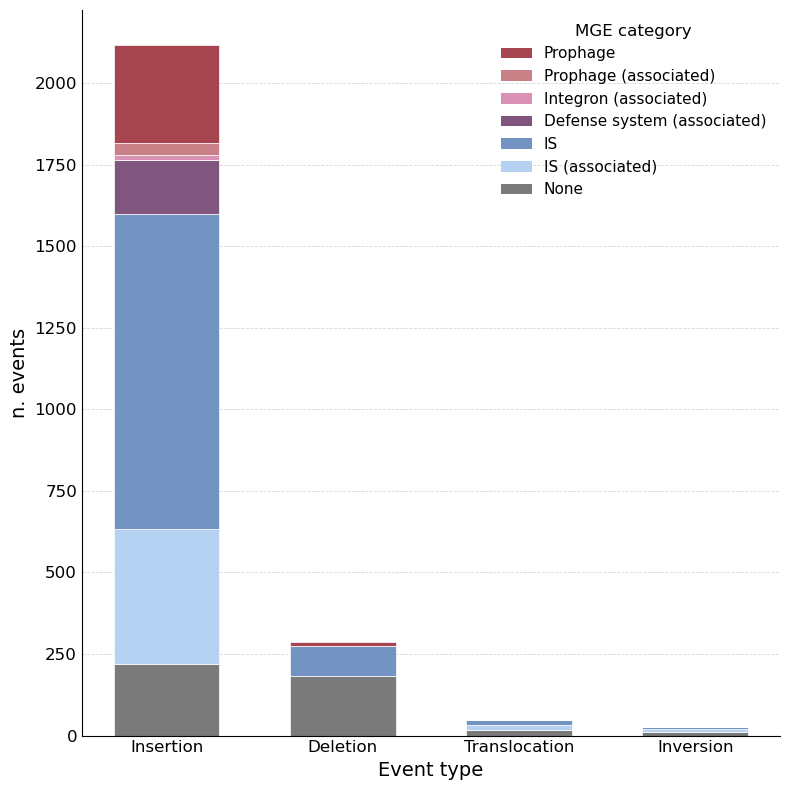

(<Figure size 800x800 with 1 Axes>,
 <Axes: xlabel='Event type', ylabel='n. events'>)

In [25]:
plot_event_mge_stacked_bar(deduplicated_events_df, figsize=(8,8))

In [20]:
# distribution of is types over insertions annotated as insertion sequences
deduplicated_events_df[deduplicated_events_df['event_type'] == "insertion"].is_family.value_counts()

is_family
IS1            528
IS66           135
IS3            134
IS21            40
IS4             36
IS1380          30
IS5             19
ISL3            15
IS30            12
IS110            8
IS200/IS605      7
new              6
IS6              3
Name: count, dtype: int64

We relate mobile genetic elements with the length distribution of insertions.

Saved figure to ../figures/insertion_length_MGE.pdf


(<Figure size 700x500 with 1 Axes>,
 <Axes: xlabel='Event length (bp)', ylabel='Count'>)

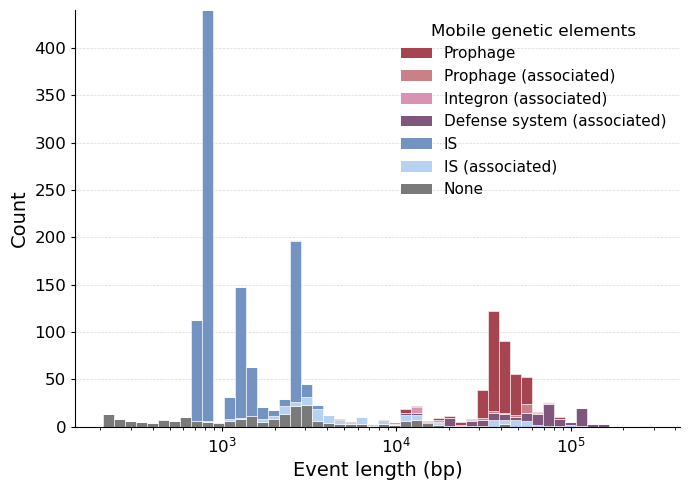

In [7]:
plot_event_length_distribution(deduplicated_events_df, event_types=['insertion'], color_by="mge",
                                min_length_threshold=200, log_y=False, log_x=True, filter_below_threshold=True, figsize=(7,5),
                                save_path="../figures/insertion_length_MGE.pdf")

Saved figure to ../figures/insertion_length_MGE_IS_family.pdf


(<Figure size 900x500 with 1 Axes>,
 <Axes: xlabel='Event length (bp)', ylabel='Count'>)

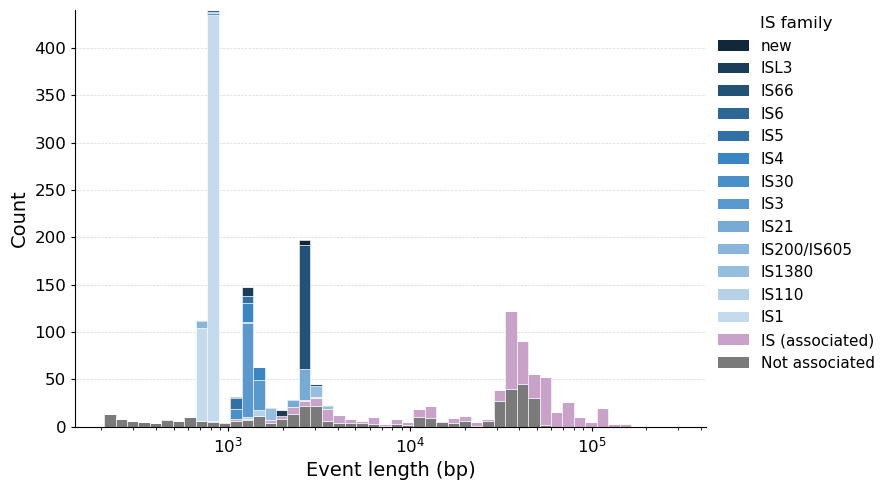

In [6]:
plot_event_length_distribution(deduplicated_events_df, event_types=['insertion'], color_by="is_family",
                               min_length_threshold=200, log_y=False, log_x=True, filter_below_threshold=True, figsize=(9,5),
                               save_path="../figures/insertion_length_MGE_IS_family.pdf")

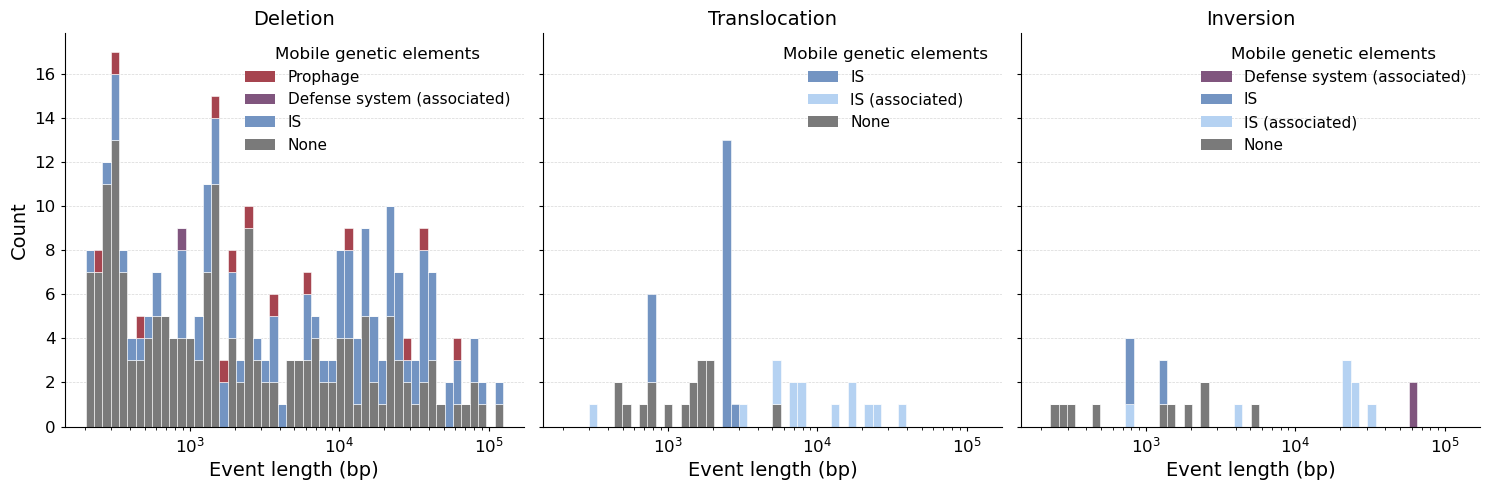

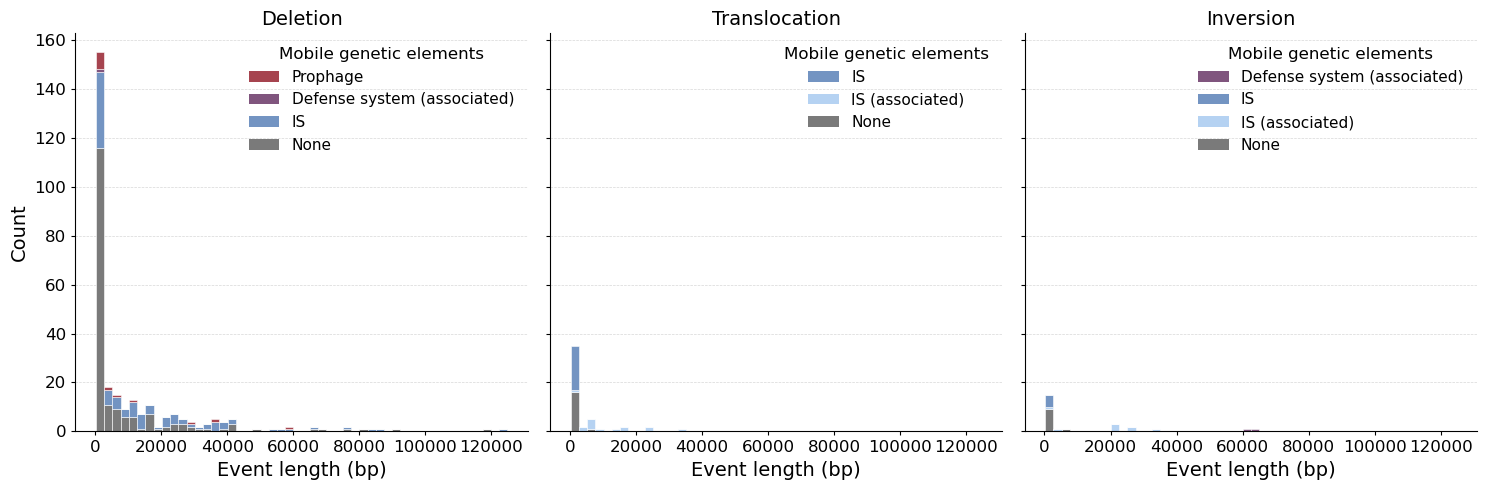

(<Figure size 1500x500 with 3 Axes>,
 array([<Axes: title={'center': 'Deletion'}, xlabel='Event length (bp)', ylabel='Count'>,
        <Axes: title={'center': 'Translocation'}, xlabel='Event length (bp)'>,
        <Axes: title={'center': 'Inversion'}, xlabel='Event length (bp)'>],
       dtype=object))

In [27]:
plot_event_length_distribution(deduplicated_events_df, event_types=['deletion', 'translocation', 'inversion'], subplot_arrangement=(1,3), figsize=(15,5),
                               color_by='mge', min_length_threshold=200, log_y=False, log_x=True, filter_below_threshold=True)
plot_event_length_distribution(deduplicated_events_df, event_types=['deletion', 'translocation', 'inversion'], subplot_arrangement=(1,3), figsize=(15,5),
                               color_by='mge', min_length_threshold=200, log_y=False, log_x=False, filter_below_threshold=True)